### More plotting with `matplotlib` and `seaborn`

Today we continue to work with `matplotlib`, focusing on customization and using subplots.  Also, the `seaborn` library will be introduced as a second visualization library with additional functionality for plotting data.

In [ ]:
#!pip install -U seaborn

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Subplots and Axes

![](https://matplotlib.org/stable/_images/users-explain-axes-index-1.2x.png)

(<Figure size 640x480 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

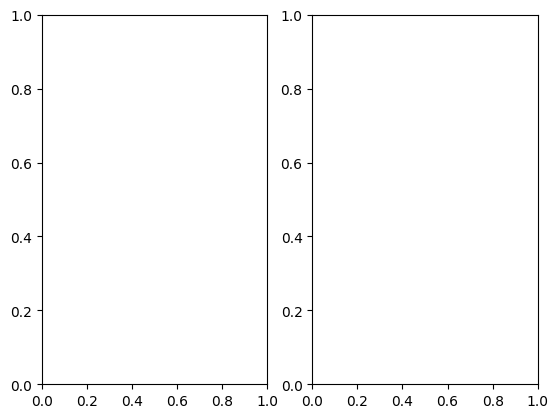

In [2]:
### create a 1 row 2 column plot
plt.subplots(nrows = 1, ncols = 2)

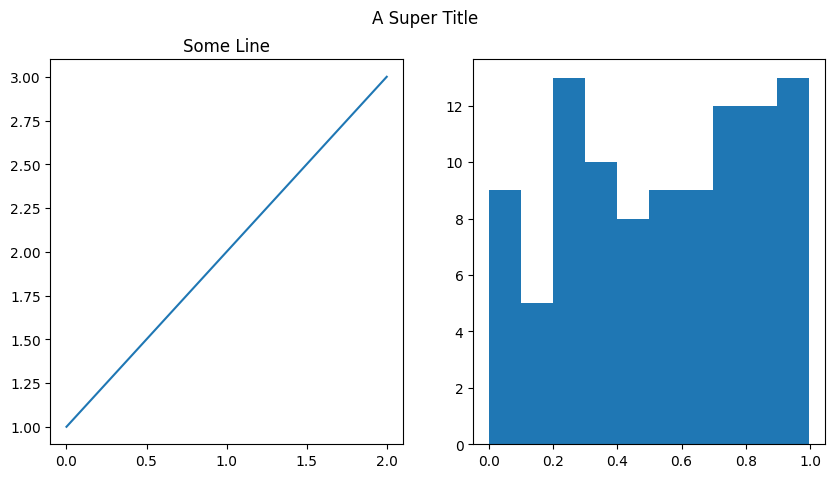

In [9]:
### add a plot to each axis
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
ax[0].plot([1, 2, 3])
ax[0].set_title('Some Line')
ax[1].hist(np.random.random(100))
fig.suptitle('A Super Title');

(array([11., 12.,  5.,  8., 19., 11., 10.,  9.,  6.,  9.]),
 array([0.00821536, 0.10686283, 0.2055103 , 0.30415776, 0.40280523,
        0.5014527 , 0.60010017, 0.69874764, 0.7973951 , 0.89604257,
        0.99469004]),
 <BarContainer object of 10 artists>)

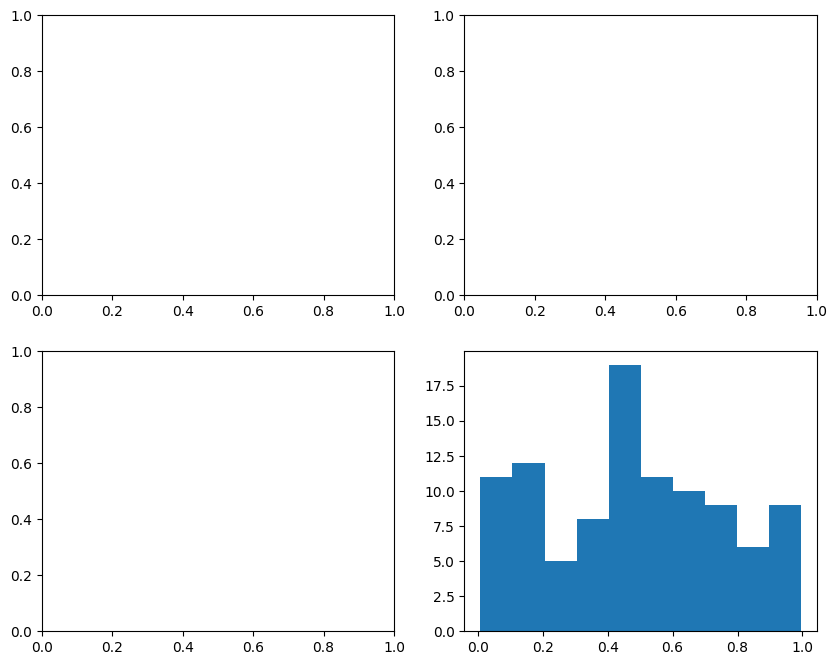

In [11]:
### create a 2 x 2 grid of plots
### add histogram to bottom right plot
fig, ax = plt.subplots(2, 2, figsize = (10, 8))
ax[1, 1].hist(np.random.random(100))

### Exploratory Data Analysis

![](https://m.media-amazon.com/images/I/41lcv%2B1JqRL._AC_SY200_QL15_.jpg)

> *Exploratory data analysis (EDA) is used by data scientists to analyze and investigate data sets and summarize their main characteristics, often employing data visualization methods.* -- [IBM](https://www.ibm.com/think/topics/exploratory-data-analysis)


#### Introduction to `seaborn`

The `seaborn` library is built on top of `matplotlib` and offers high level visualization tools for plotting data.  Typically a call to the `seaborn` library looks like:

```
sns.plottype(data = DataFrame, x = x, y = y, additional arguments...)
```

In [12]:
### load a sample dataset on tips
tips = sns.load_dataset('tips')
tips.head(2)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3


<Axes: xlabel='tip'>

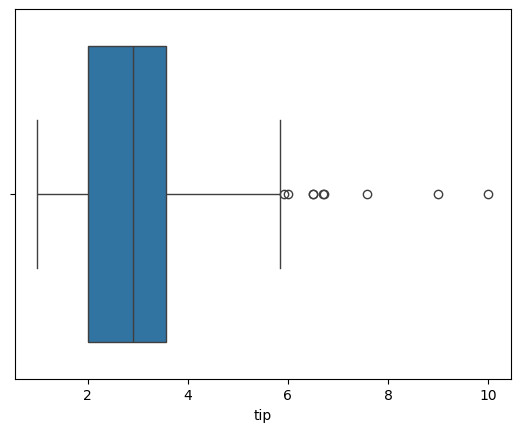

In [13]:
### boxplot of tips
sns.boxplot(data = tips, x = 'tip')

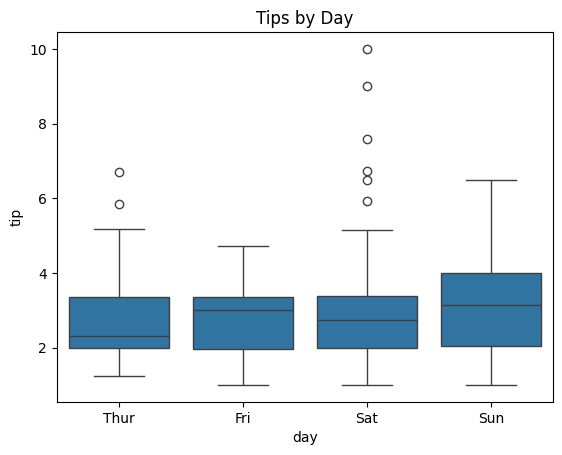

In [14]:
### boxplot of tips by day
sns.boxplot(data = tips, x = 'day', y = 'tip')
plt.title('Tips by Day');

#### `hue`

The `hue` argument works like a grouping helper with `seaborn`.  Plots that have this argument will break the data into groups from the passed column and add an appropriate legend.

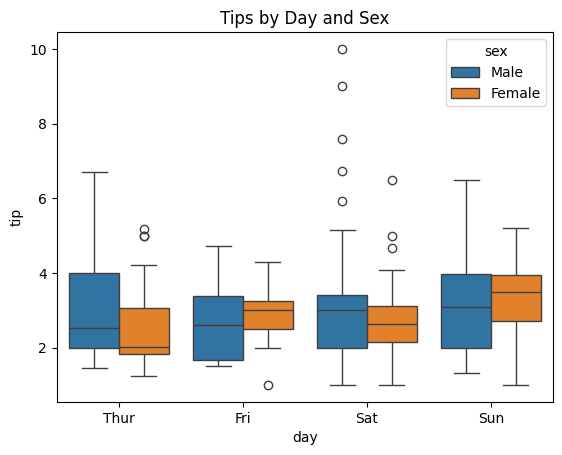

In [17]:
### boxplot of tips by day by smoker
sns.boxplot(data = tips, x = 'day', y = 'tip', hue = 'sex')
plt.title('Tips by Day and Sex');

#### `displot`

For visualizing one dimensional distributions of data.

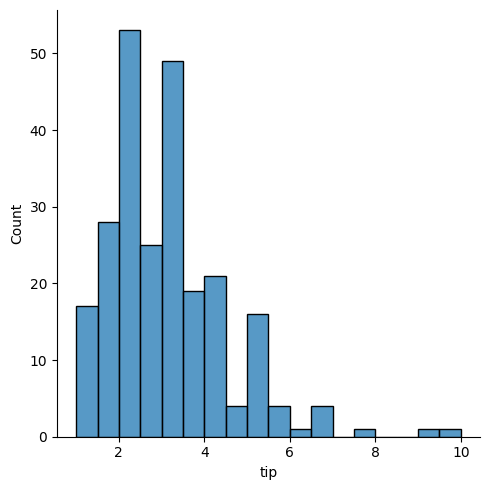

In [18]:
### histogram of tips
sns.displot(data = tips, x = 'tip')

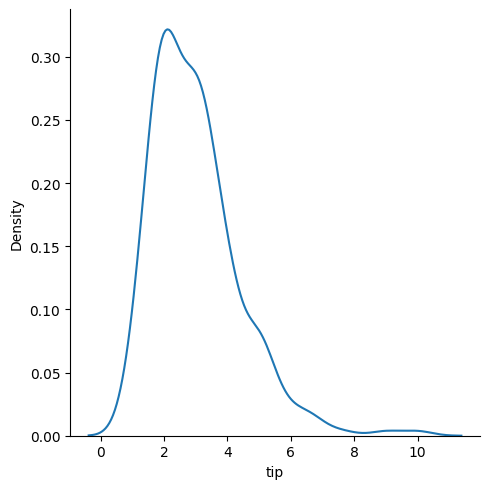

In [19]:
### kde plot
sns.displot(data = tips, x = 'tip', kind = 'kde')

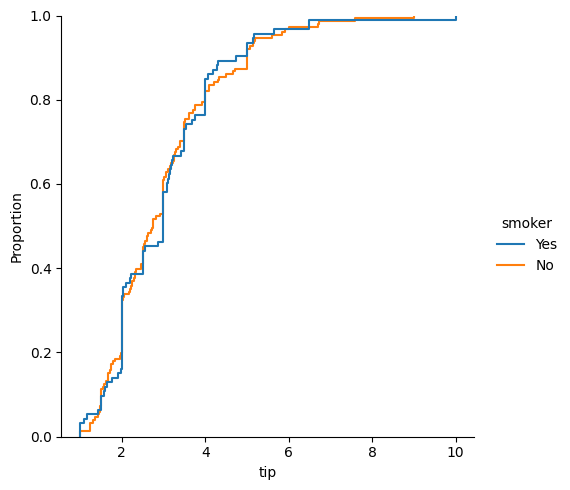

In [20]:
### empirical cumulative distribution plot of tips by smoker
sns.displot(data = tips, x = 'tip', kind = 'ecdf', hue = 'smoker')

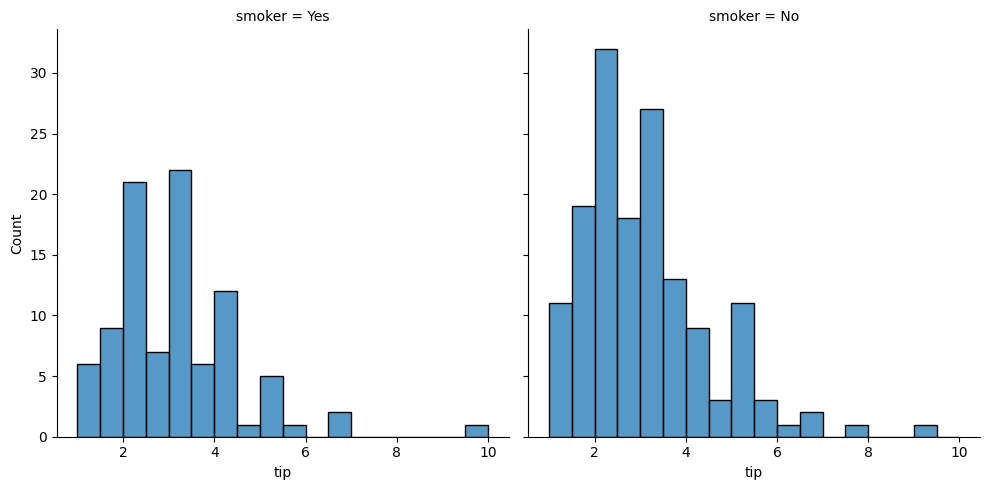

In [21]:
### using the col argument
sns.displot(data = tips, x = 'tip', col = 'smoker')

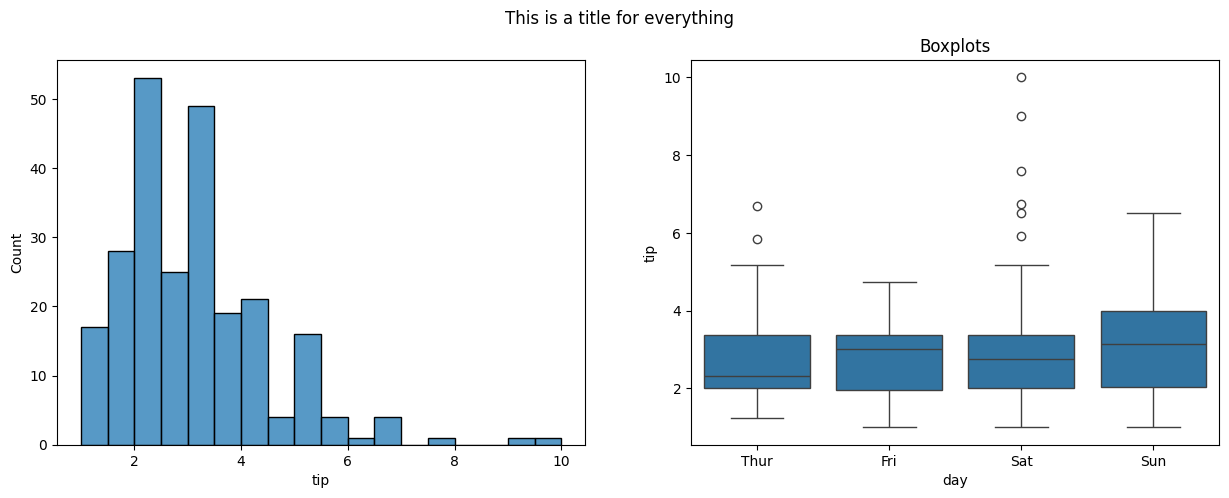

In [22]:
#draw a histogram and a boxplot using seaborn on two axes
fig, ax = plt.subplots(1, 2, figsize = (15, 5))
sns.histplot(data = tips, x = 'tip', ax = ax[0])
sns.boxplot(data = tips, x = 'day', y = 'tip', ax = ax[1])
ax[1].set_title('Boxplots')
fig.suptitle('This is a title for everything');

#### `relplot`

For visualizing relationships.

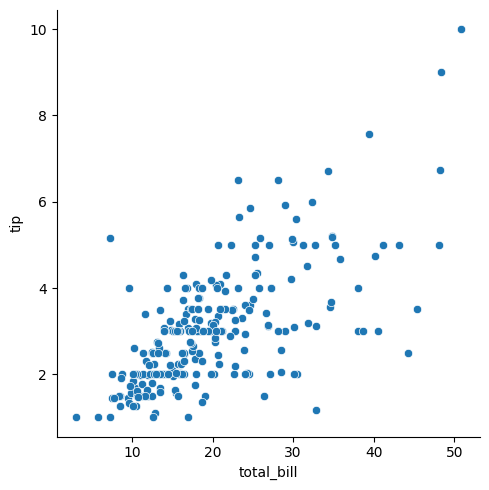

In [23]:
### relplot of bill vs. tip
sns.relplot(data = tips, x = 'total_bill', y = 'tip')

<Axes: xlabel='total_bill', ylabel='tip'>

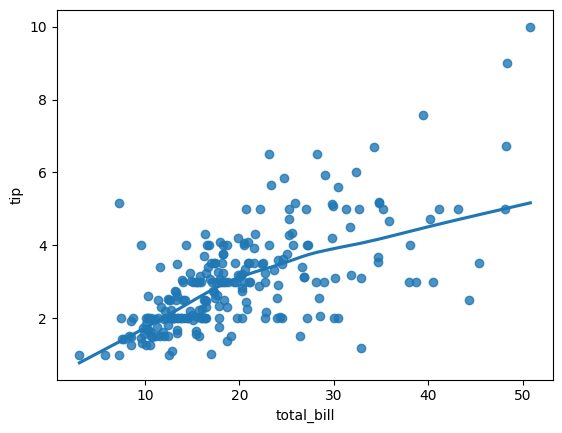

In [24]:
### regression plot
sns.regplot(data = tips, x ='total_bill', y = 'tip', lowess = True )

<Axes: xlabel='smoker', ylabel='tip'>

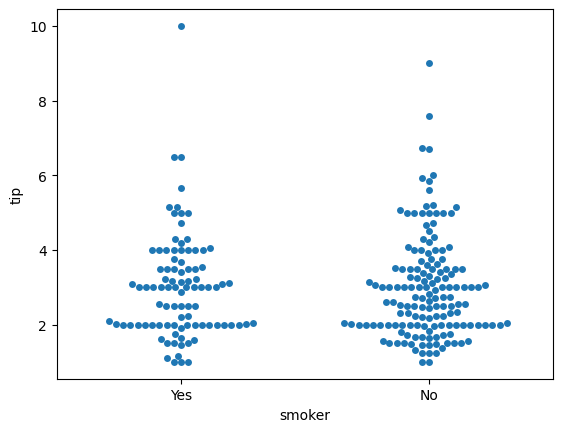

In [25]:
### swarm
sns.swarmplot(data = tips, x = 'smoker', y = 'tip')

<Axes: xlabel='smoker', ylabel='tip'>

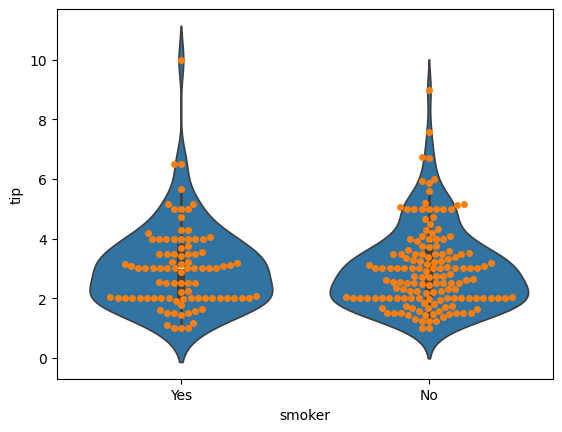

In [27]:
### violin plot
sns.violinplot(data = tips, x = 'smoker', y = 'tip')
sns.swarmplot(data = tips, x = 'smoker', y = 'tip')

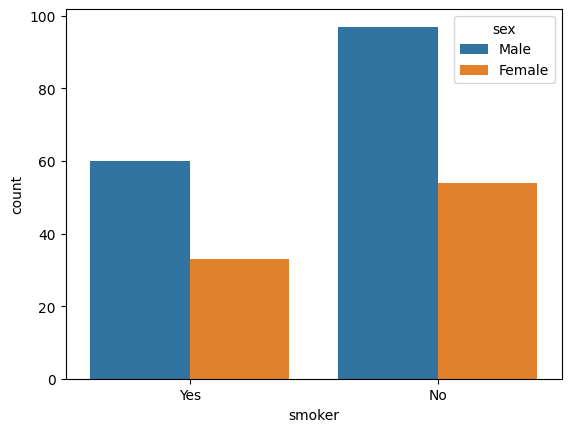

In [29]:
### countplot
sns.countplot(data = tips, x = 'smoker', hue = 'sex');

#### Additional Plots

- `pairplot`
- `heatmap`

In [30]:
penguins = sns.load_dataset('penguins').dropna()

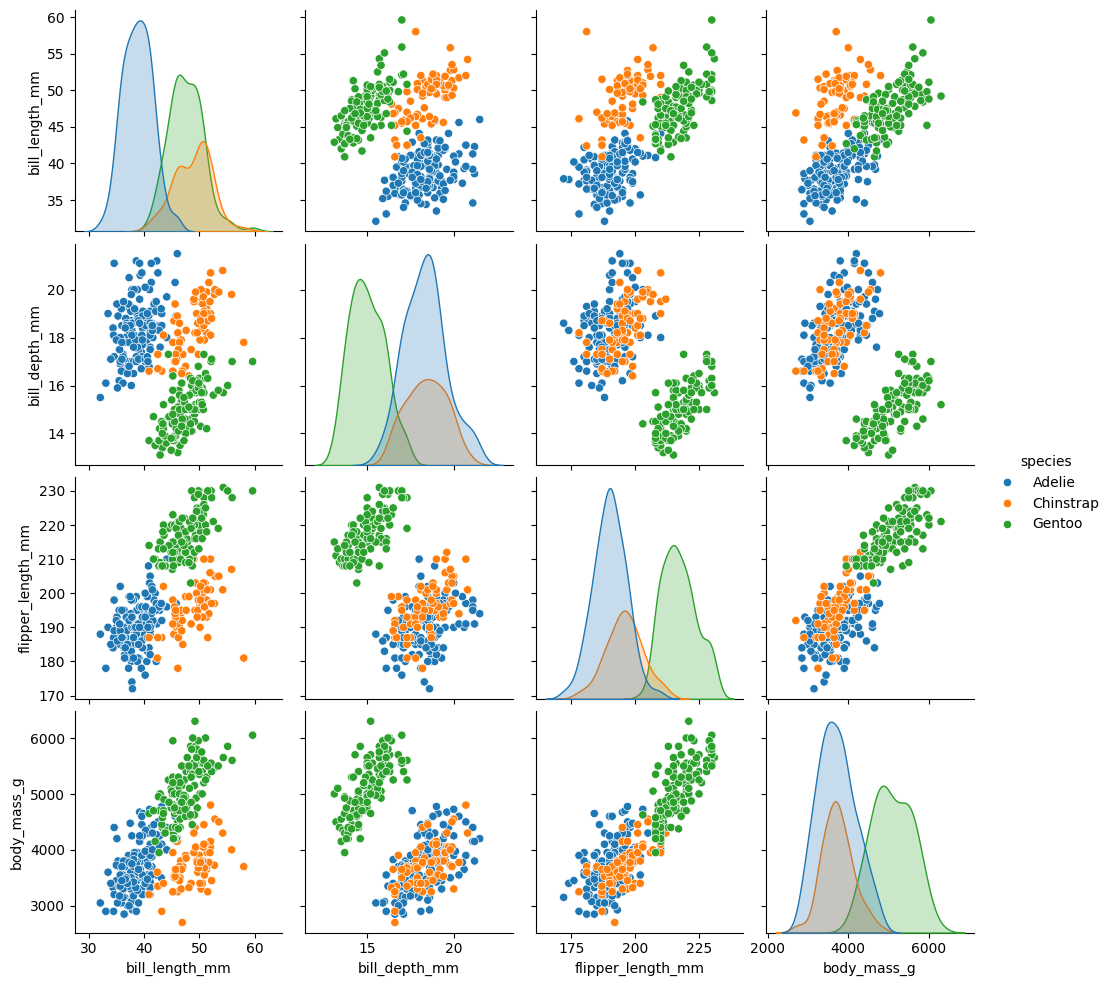

In [31]:
### pairplot of penguins colored by species
sns.pairplot(data = penguins, hue = 'species', diag_kind = 'kde')

In [32]:
### housing data
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame = True).frame
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#### Plotting Correlations

Correlation captures the strength of a linear relationship between features.  Often, this is easier to look at than a scatterplot of the data to establish relationships, however recall that this is only a detector for *linear* relationships!

In [33]:
### correlation in data
housing.corr(numeric_only = True)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


<Axes: >

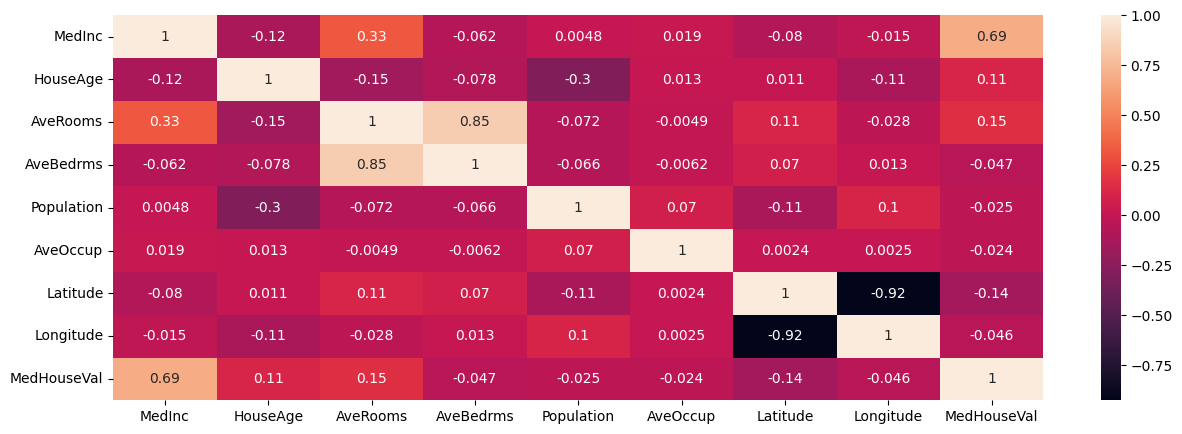

In [34]:
### heatmap of correlations
plt.figure(figsize = (15, 5))
sns.heatmap(housing.corr(numeric_only=True), annot = True)

#### Problems

Use the `diabetes` data below loaded from OpenML ([docs](https://www.openml.org/search?type=data&sort=runs&status=active&id=37)).  

In [35]:
from sklearn.datasets import fetch_openml

In [36]:
diabetes = fetch_openml(data_id = 37).frame

In [37]:
diabetes.head()

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,tested_positive
1,1,85,66,29,0,26.6,0.351,31,tested_negative
2,8,183,64,0,0,23.3,0.672,32,tested_positive
3,1,89,66,23,94,28.1,0.167,21,tested_negative
4,0,137,40,35,168,43.1,2.288,33,tested_positive


1. Plot distribution of ages separated by class.

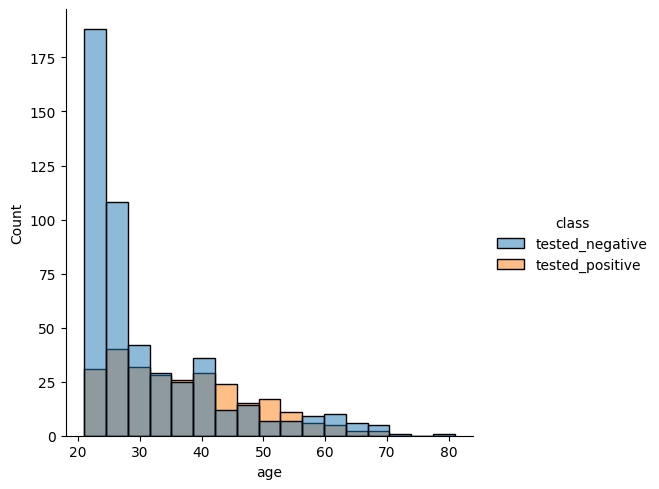

In [39]:
sns.displot(data = diabetes, x = 'age', hue = 'class')

2. Use the plots below to determine which feature has the most distinct difference between classes?

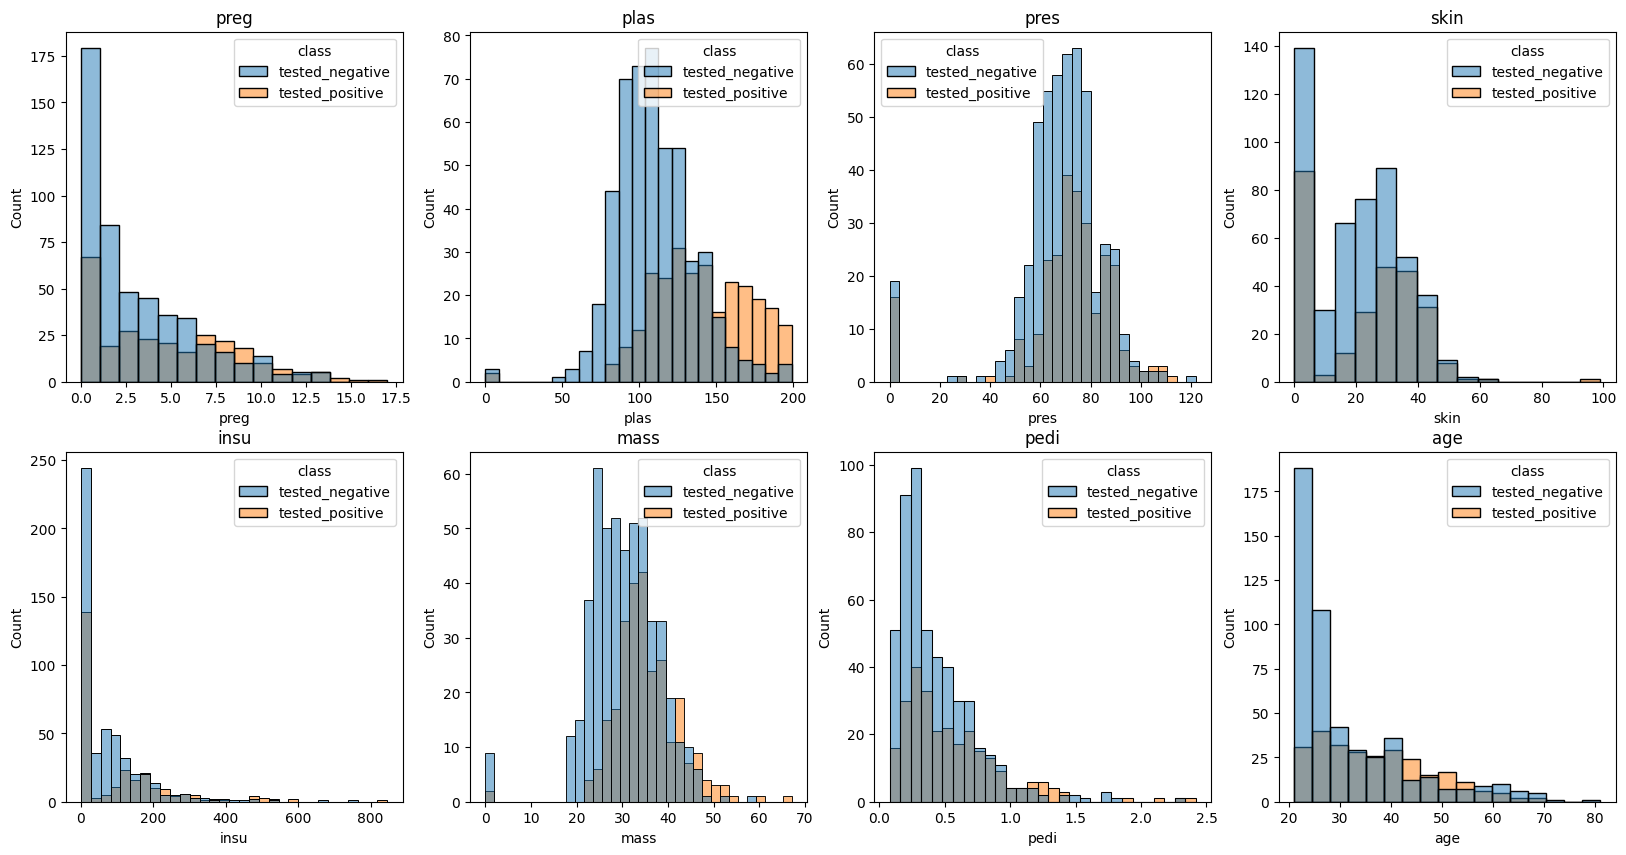

In [40]:
fig, ax = plt.subplots(2, 4, figsize = (20, 10))
colnum = 0
for row in range(2):
    for col in range(4):
        sns.histplot(data = diabetes, x = diabetes.iloc[:,colnum], hue = 'class', ax =  ax[row, col])
        ax[row,col].set_title(diabetes.columns.tolist()[colnum])
        colnum += 1

In [44]:
#Looks like plasticity shows the biggest difference between the group that 
#tested positive and those that tested negative.

3. Head over the the seaborn documentation [here](https://seaborn.pydata.org/). Find a different plot type or function and implement it using the diabetes data.

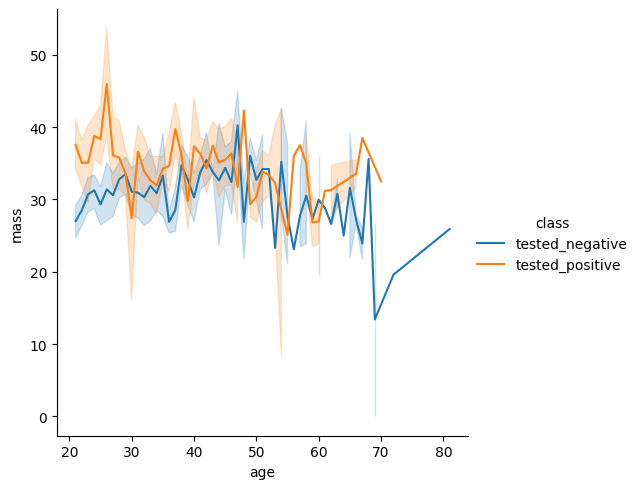

In [43]:
sns.relplot(data = diabetes, x = 'age', y = 'mass', kind = 'line', hue = 'class')

### Partner Exercise

- What time of year is most popular for bike rentals? 
- What’s the most popular day of the week for bike rentals?
- What’s the frequency of use for the average user? 
- What are the most and least congested bike stations?

In [ ]:
bikeshare_hour = pd.read_csv('data/hour.csv')

In [ ]:
bikeshare_hour.head()